<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Project_4_Spotify_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns

## Read in Data

In [2]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [3]:
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: AM1S5nzudg4jOkGbSohdE+cTd/VtAQNu43wM0ChiIIR41ztHKJ+e/XKzhQcBrxDctt/QV/bnI0JkJORNXB718TMNFKehEek5
x-amz-request-id: 1JJ1T8BXHDXC72VP
Date: Wed, 20 May 2026 15:25:05 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [4]:
!curl -s  {url}| head -10 | cat -n

     1	Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
     2	1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,"2021-07-23--2021-07-30
     3	2021-07-16--2021-07-23
     4	2021-07-09--2021-07-16
     5	2021-07-02--2021-07-09
     6	2021-06-25--2021-07-02
     7	2021-06-18--2021-06-25
     8	2021-06-11--2021-06-18
     9	2021-06-04--2021-06-11",100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
    10	2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,"2021-07-23--2021-07-30


In [5]:
#spotify = pd.read_csv( url, index_col = 0 )#this makes the index 0 column my index column.  In this case, I do not want to do that.


In [6]:
spotify = pd.read_csv(url)
spotify

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


In [7]:
spotify.head()


,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


In [8]:
spotify.shape


(1556, 23)

In [9]:
spotify.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

## Clean the data

In [10]:
spotify_2 = spotify[['Highest Charting Position','Energy','Danceability','Loudness','Speechiness','Acousticness','Liveness','Tempo','Valence','Chord']]
spotify_2

,Highest Charting Position,Energy,Danceability,Loudness,Speechiness,Acousticness,Liveness,Tempo,Valence,Chord
0,1,0.8,0.714,-4.808,0.0504,0.127,0.359,134.002,0.589,B
1,2,0.764,0.591,-5.484,0.0483,0.0383,0.103,169.928,0.478,C#/Db
2,1,0.664,0.563,-5.044,0.154,0.335,0.0849,166.928,0.688,A
3,3,0.897,0.808,-3.712,0.0348,0.0469,0.364,126.026,0.591,B
4,5,0.704,0.736,-7.409,0.0615,0.0203,0.0501,149.995,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...
1551,195,0.7,0.762,-6.021,0.0694,0.00261,0.153,116.073,0.608,A
1552,196,0.87,0.528,-3.123,0.0851,0.24,0.333,152.37,0.714,B
1553,197,0.523,0.765,-4.333,0.03,0.184,0.132,104.988,0.394,D
1554,198,0.55,0.832,-7.026,0.0587,0.249,0.182,154.064,0.881,F


In [11]:
(spotify_2['Energy'] ==  ' ').sum()

np.int64(11)

In [12]:
(spotify_2['Danceability'] ==  ' ').sum()

np.int64(11)

In [13]:
(spotify_2['Loudness'] ==  ' ').sum()

np.int64(11)

In [14]:
(spotify_2['Speechiness'] ==  ' ').sum()

np.int64(11)

In [15]:
(spotify_2['Acousticness'] ==  ' ').sum()

np.int64(11)

In [16]:
(spotify_2['Liveness'] ==  ' ').sum()

np.int64(11)

In [17]:
(spotify_2['Tempo'] ==  ' ').sum()

np.int64(11)

In [18]:
(spotify_2['Valence'] ==  ' ').sum()

np.int64(11)

In [19]:
(spotify_2['Chord'] ==  ' ').sum()

np.int64(11)

### Create the dataframe

In [20]:
# 1. Subset the DataFrame to include only your desired columns
columns_to_keep = [
    "Highest Charting Position",
    "Energy",
    "Danceability",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Liveness",
    "Tempo",
    "Valence",
]
columns_to_keep

['Highest Charting Position',
 'Energy',
 'Danceability',
 'Loudness',
 'Speechiness',
 'Acousticness',
 'Liveness',
 'Tempo',
 'Valence']

In [21]:
# create df copy
spotify_sub = spotify_2[columns_to_keep].copy()

In [22]:
# 2. Replace empty spaces (and multiple spaces) with NaN, then drop those rows
# Use .copy() at the end to explicitly create a fresh copy for you to work on
spotify_clean = (
    spotify_sub.replace(r"^\s*$", np.nan, regex=True).dropna().copy()
)
spotify_clean

,Highest Charting Position,Energy,Danceability,Loudness,Speechiness,Acousticness,Liveness,Tempo,Valence
0,1,0.8,0.714,-4.808,0.0504,0.127,0.359,134.002,0.589
1,2,0.764,0.591,-5.484,0.0483,0.0383,0.103,169.928,0.478
2,1,0.664,0.563,-5.044,0.154,0.335,0.0849,166.928,0.688
3,3,0.897,0.808,-3.712,0.0348,0.0469,0.364,126.026,0.591
4,5,0.704,0.736,-7.409,0.0615,0.0203,0.0501,149.995,0.894
...,...,...,...,...,...,...,...,...,...
1551,195,0.7,0.762,-6.021,0.0694,0.00261,0.153,116.073,0.608
1552,196,0.87,0.528,-3.123,0.0851,0.24,0.333,152.37,0.714
1553,197,0.523,0.765,-4.333,0.03,0.184,0.132,104.988,0.394
1554,198,0.55,0.832,-7.026,0.0587,0.249,0.182,154.064,0.881


In [23]:
# Verify the results
print(f"Original row count: {len(spotify_sub)}")
print(f"Cleaned row count: {len(spotify_clean)}")

Original row count: 1556
Cleaned row count: 1545


In [24]:
spotify_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Highest Charting Position  1545 non-null   int64 
 1   Energy                     1545 non-null   object
 2   Danceability               1545 non-null   object
 3   Loudness                   1545 non-null   object
 4   Speechiness                1545 non-null   object
 5   Acousticness               1545 non-null   object
 6   Liveness                   1545 non-null   object
 7   Tempo                      1545 non-null   object
 8   Valence                    1545 non-null   object
dtypes: int64(1), object(8)
memory usage: 120.7+ KB


In [25]:
# Convert all columns to float
spotify_clean = spotify_clean.astype(float)


In [26]:

# Verify the data types
print(spotify_clean.dtypes)

Highest Charting Position    float64
Energy                       float64
Danceability                 float64
Loudness                     float64
Speechiness                  float64
Acousticness                 float64
Liveness                     float64
Tempo                        float64
Valence                      float64
dtype: object


In [27]:
spotify_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 0 to 1555
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1545 non-null   float64
 1   Energy                     1545 non-null   float64
 2   Danceability               1545 non-null   float64
 3   Loudness                   1545 non-null   float64
 4   Speechiness                1545 non-null   float64
 5   Acousticness               1545 non-null   float64
 6   Liveness                   1545 non-null   float64
 7   Tempo                      1545 non-null   float64
 8   Valence                    1545 non-null   float64
dtypes: float64(9)
memory usage: 120.7 KB


## EDA



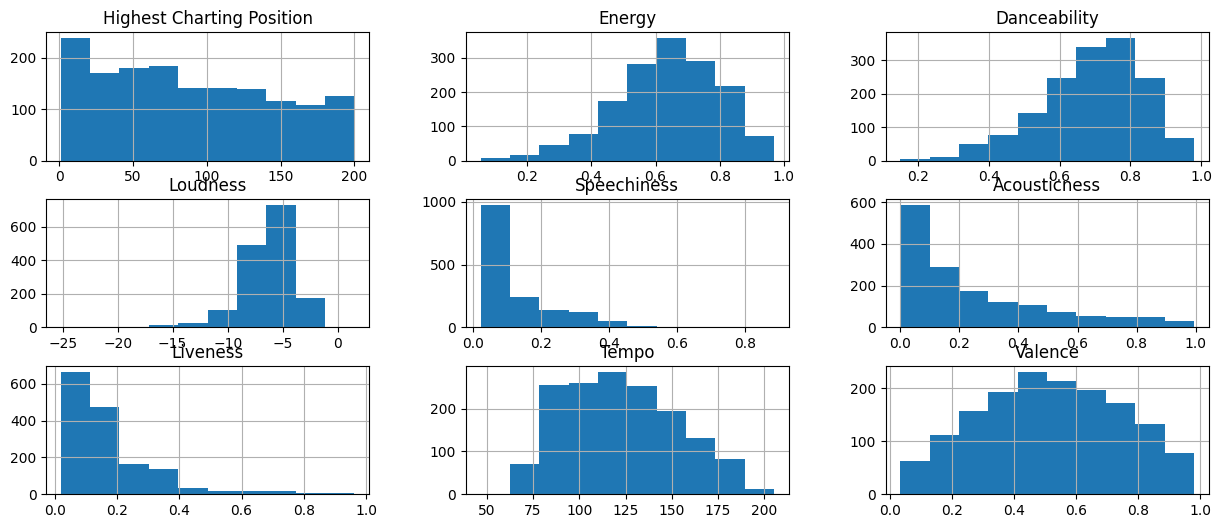

In [28]:
spotify_clean.hist(figsize=(15,6));
plt.savefig('mvp1.png')

### Analyze the data

## RG Boost


In [29]:
X = spotify_clean.drop('Highest Charting Position', axis = 1)#it chooses all columns minus the target
y = spotify_clean['Highest Charting Position']


In [30]:
numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15)
  xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 63.40010588101699


## Optimizing RG Boost parameters


In [31]:
# Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [ 1, 2, 3, 4, 5, 6, 7 ],#can use range also
 'learning_rate' : [ 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}


In [32]:
# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

In [33]:
# Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42 )
model = gsearch.fit(X_train,y_train)


In [34]:
# See grid search results
print(model.best_params_)


{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 10}


Now we will fit our XGBoost model with the best parameters

In [35]:
params = model.best_params_#use a loop to have all the parameters chosen

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.15 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.2,
      # max_depth = 2,
      # n_estimators = 10,
      seed = 10,
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')


RMSE: 57.40165283056675


Average RMSE: 57.798389440717195


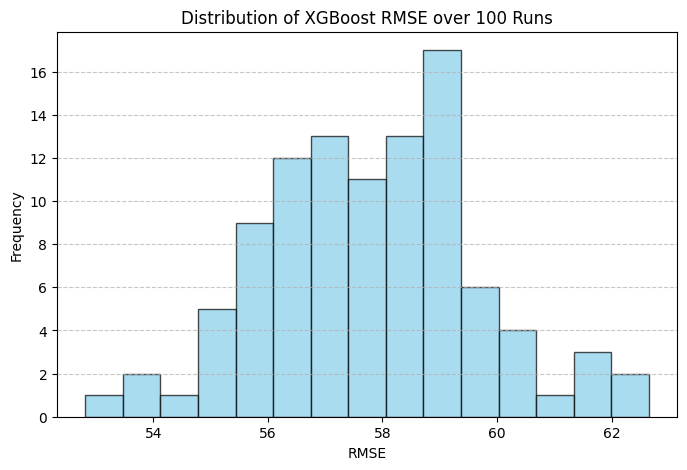

In [36]:

params = model.best_params_

numLoops = 100
# Change this to store RMSE directly to make plotting and math simpler
rmse_xgb = np.zeros(numLoops)

for idx in range(0, numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)
    xgbr = xgb.XGBRegressor(
        objective="reg:squarederror",
        verbosity=0,
        **params,
         # Note: For true loop diversity, consider removing or changing the seed per loop
    )
    xgbr.fit(X_train, y_train)
    y_pred_xgb = xgbr.predict(X_test)

    # Calculate and store RMSE directly
    rmse_xgb[idx] = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Average RMSE: {rmse_xgb.mean()}")

# --- 1. Plot Histogram of RMSEs ---
plt.figure(figsize=(8, 5))
plt.hist(rmse_xgb, bins=15, color="skyblue", edgecolor="black", alpha=0.7)
plt.title("Distribution of XGBoost RMSE over 100 Runs")
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig(
    "Distribution of XGBoost RMSE.png",
    dpi=300,
)
plt.show()



<Figure size 4000x3000 with 0 Axes>

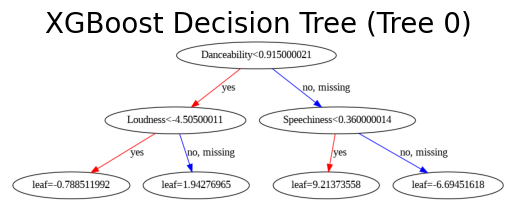

In [37]:
# --- 2. Plot the Decision Tree ---
# We will plot a tree from the last trained model 'xgbr'
plt.figure(figsize=(40, 30))  # Trees can be wide and deep, keeping it large helps readability

# Changed rankdir='LR' to rankdir='TB' for Top-to-Bottom
xgb.plot_tree(xgbr, tree_idx=0, rankdir="TB")

plt.title("XGBoost Decision Tree (Tree 0)", fontsize=20)

# --- Save the plot to your drive ---
# Using dpi=300 and bbox_inches='tight' is especially important for trees so the text stays crisp
plt.savefig(
    "xgb_decision_tree.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)

# Display the tree on the screen
plt.show()

### Understanding the tree

In [38]:
# Convert all trees to a pandas DataFrame
tree_df = xgbr.get_booster().trees_to_dataframe()

# Filter for just the first tree (Tree 0) and look at the split nodes
tree_0 = tree_df[tree_df['Tree'] == 0]

# Display relevant columns: feature name, threshold value, and where it leads
print(tree_0[['Node', 'Feature', 'Split', 'Yes', 'No', 'Gain']])

   Node       Feature  Split  Yes   No          Gain
0     0  Danceability  0.915  0-1  0-2  48425.168000
1     1      Loudness -4.505  0-3  0-4  40716.847700
2     2   Speechiness  0.360  0-5  0-6  20941.394500
3     3          Leaf    NaN  NaN  NaN     -0.788512
4     4          Leaf    NaN  NaN  NaN      1.942770
5     5          Leaf    NaN  NaN  NaN      9.213736
6     6          Leaf    NaN  NaN  NaN     -6.694516


## Find Important Predictors

/tmp/ipykernel_4327/362214512.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


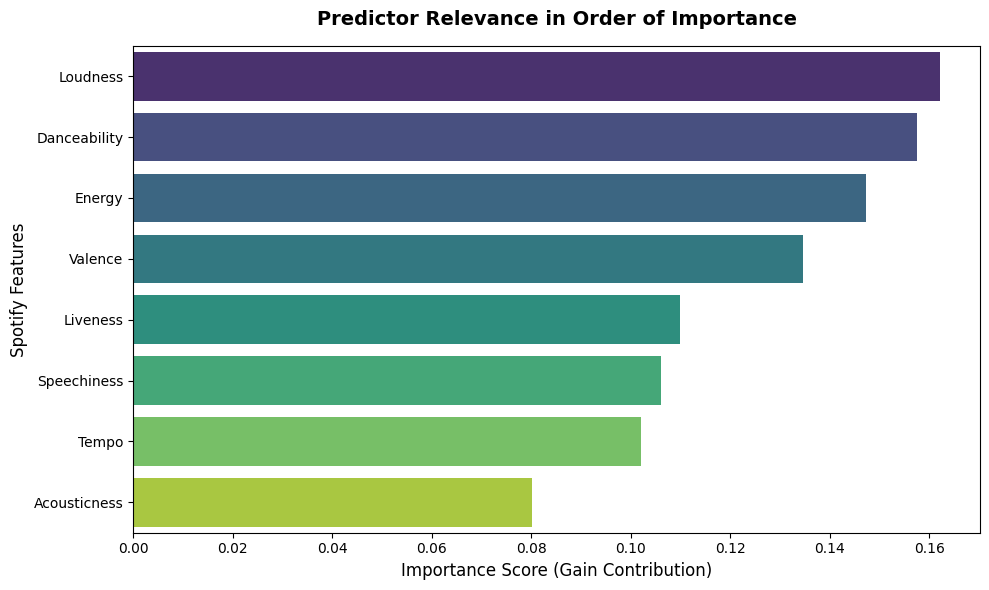

In [42]:
# this code is what Gemini recommended.  Compare with code from lecture.
# 1. Extract feature importances and pair them with column names
# (Assuming 'xgbr' is your trained model and 'X' is your DataFrame of predictors)
feature_relevance = pd.Series(xgbr.feature_importances_, index=X.columns)

# 2. Sort the features from most relevant to least relevant
feature_relevance_sorted = feature_relevance.sort_values(ascending=False)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Use Seaborn's barplot with the sorted data
sns.barplot(
    x=feature_relevance_sorted.values,
    y=feature_relevance_sorted.index,
    palette="viridis",  # Dark-to-light color palette highlights the top features
)

# 4. Customize labels and titles
plt.title(
    "Predictor Relevance in Order of Importance",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Importance Score (Gain Contribution)", fontsize=12)
plt.ylabel("Spotify Features", fontsize=12)

# Adjust layout to make sure no text labels are cut off at the edges
plt.tight_layout()

# 5. Optional: Save the plot as a PNG image before displaying
plt.savefig("sorted_predictor_relevance.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

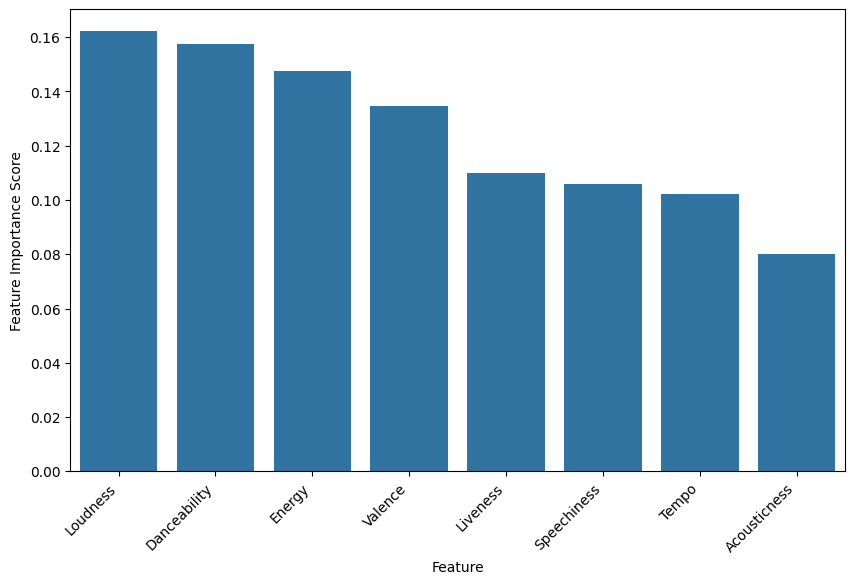

In [41]:
#this code is from the lectures.
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values( ascending = False )
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values )
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score') ;

Mean CV RMSE: 57.5810


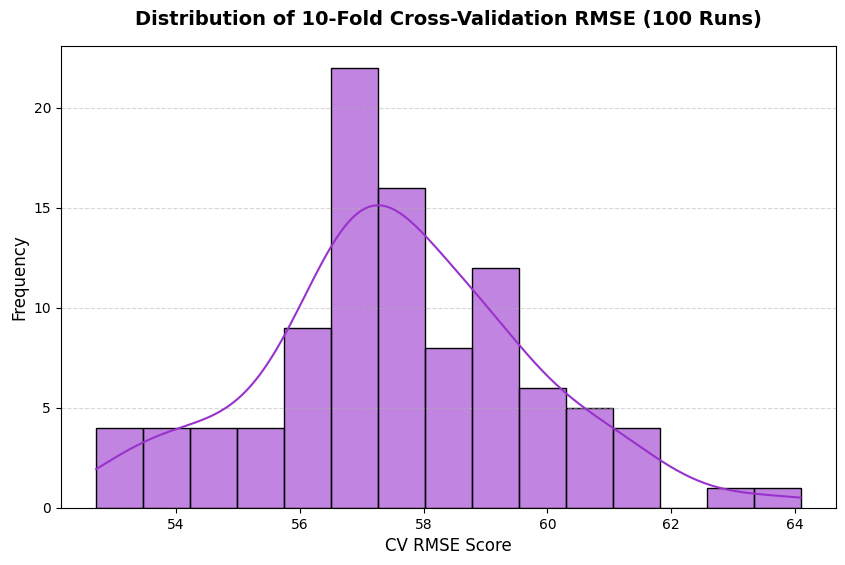

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
# import xgboost as xgb
# from sklearn.model_selection import RepeatedKFold, cross_val_score

# params = model.best_params_

# # 1. Initialize your model
# xgbr = xgb.XGBRegressor(objective="reg:squarederror", verbosity=0, **params)

# # 2. Use RepeatedKFold to get 100 total scores (10 splits x 10 repetitions)
# cv_strategy = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)

# # 3. Calculate MSE across all repetitions and convert to positive
# cv_mse = -cross_val_score(
#     xgbr, X, y, scoring="neg_mean_squared_error", cv=cv_strategy, n_jobs=-1
# )

# # 4. Turn MSE into RMSE
# cv_rmse_scores = np.sqrt(cv_mse)

# print(f"Mean CV RMSE: {cv_rmse_scores.mean():.4f}")

# # --- 5. Plot the Histogram ---
# plt.figure(figsize=(10, 6))

# # Plotting the distribution with a smooth KDE (Kernel Density Estimate) line
# sns.histplot(
#     cv_rmse_scores,
#     bins=15,
#     kde=True,
#     color="darkorchid",
#     edgecolor="black",
#     alpha=0.6,
# )

# # Customizing titles and axes
# plt.title(
#     "Distribution of 10-Fold Cross-Validation RMSE (100 Runs)",
#     fontsize=14,
#     fontweight="bold",
#     pad=15,
# )
# plt.xlabel("CV RMSE Score", fontsize=12)
# plt.ylabel("Frequency", fontsize=12)
# plt.grid(axis="y", linestyle="--", alpha=0.5)

# # Optional: Save the plot to your drive before showing it
# plt.savefig("cv_rmse_distribution.png", dpi=300, bbox_inches="tight")

# plt.show()